# RSVP Experiments Notebook
This notebook recreates the RSVP lattice experiments:
- torsion-driven flow + vorticity suppression
- irreversible history field $\chi$
- history-coupled equilibrium score $E_s(x,t)$ and phase $\theta(t)$
- torsion-suppressed entropy production
- entropy caps → phase plateaus
- optional mapping of flow to quantum gate angles (if Qiskit installed)


In [3]:

import os, textwrap

modules = {"rsvp_torsion_flow.py": "#!/usr/bin/env python3\n\"\"\"\nRSVP torsion-driven flow field\n--------------------------------\nFlow is generated by vorticity gradients and damped by\nexplicit vorticity suppression (torsion regularization).\n\"\"\"\nimport numpy as np\n\ndef roll(a, s, ax): return np.roll(a, s, axis=ax)\n\ndef grad_x(f, dx): return (roll(f, -1, 1) - roll(f, 1, 1)) / (2*dx)\ndef grad_y(f, dy): return (roll(f, -1, 0) - roll(f, 1, 0)) / (2*dy)\n\ndef laplacian(f, dx, dy):\n    return ((roll(f,-1,1) - 2*f + roll(f,1,1))/(dx*dx)\n          + (roll(f,-1,0) - 2*f + roll(f,1,0))/(dy*dy))\n\ndef advect(f, vx, vy, dx, dy):\n    fx = np.where(vx >= 0, (f - roll(f,1,1))/dx,\n                           (roll(f,-1,1)-f)/dx)\n    fy = np.where(vy >= 0, (f - roll(f,1,0))/dy,\n                           (roll(f,-1,0)-f)/dy)\n    return -(vx*fx + vy*fy)\n\ndef curl_z(vx, vy, dx, dy):\n    return grad_x(vy, dx) - grad_y(vx, dy)\n\ndef perp_grad(f, dx, dy):\n    return -grad_y(f, dy), grad_x(f, dx)\n\ndef step_flow(vx, vy, Phi, S, dx, dy, p):\n    \"\"\"\n    v_t = torsion_drive - vorticity_penalty - damping + viscosity\n    \"\"\"\n    \u03c9 = curl_z(vx, vy, dx, dy)\n\n    # torsion drive: \u2207\u22a5\u03c9\n    tx, ty = perp_grad(\u03c9, dx, dy)\n\n    # vorticity suppression (penalize large \u03c9)\n    pen_x = grad_x(\u03c9**2, dx)\n    pen_y = grad_y(\u03c9**2, dy)\n\n    advvx = advect(vx, vx, vy, dx, dy)  # -v\u00b7\u2207vx\n    advvy = advect(vy, vx, vy, dx, dy)\n\n    dvx = (\n        advvx\n        + p[\"lambda\"] * tx\n        - p[\"gamma\"] * pen_x\n        - p[\"nu\"] * vx\n        + p[\"kv\"] * laplacian(vx, dx, dy)\n    )\n\n    dvy = (\n        advvy\n        + p[\"lambda\"] * ty\n        - p[\"gamma\"] * pen_y\n        - p[\"nu\"] * vy\n        + p[\"kv\"] * laplacian(vy, dx, dy)\n    )\n\n    return vx + p[\"dt\"]*dvx, vy + p[\"dt\"]*dvy\n", "rsvp_history_field.py": "#!/usr/bin/env python3\n\"\"\"\nRSVP irreversible history field chi(x,t)\n----------------------------------------\nChi accumulates entropy and feeds back\ninto Phi and entropy dynamics.\n\"\"\"\nimport numpy as np\n\ndef roll(a, s, ax): return np.roll(a, s, axis=ax)\n\ndef grad_x(f, dx): return (roll(f,-1,1) - roll(f,1,1)) / (2*dx)\ndef grad_y(f, dy): return (roll(f,-1,0) - roll(f,1,0)) / (2*dy)\n\ndef laplacian(f, dx, dy):\n    return ((roll(f,-1,1)-2*f+roll(f,1,1))/(dx*dx)\n          + (roll(f,-1,0)-2*f+roll(f,1,0))/(dy*dy))\n\ndef advect(f, vx, vy, dx, dy):\n    fx = np.where(vx>=0, (f-roll(f,1,1))/dx,\n                          (roll(f,-1,1)-f)/dx)\n    fy = np.where(vy>=0, (f-roll(f,1,0))/dy,\n                          (roll(f,-1,0)-f)/dy)\n    return -(vx*fx + vy*fy)\n\ndef step_chi(chi, S, vx, vy, dx, dy, p):\n    \"\"\"\n    chi_t = accumulation - decay + diffusion + advection\n    \"\"\"\n    dchi = (\n        advect(chi, vx, vy, dx, dy)\n        + p[\"a\"] * S\n        - p[\"b\"] * chi\n        + p[\"kchi\"] * laplacian(chi, dx, dy)\n    )\n    return chi + p[\"dt\"] * dchi\n\ndef phi_modifier(chi, p):\n    return 1.0 / (1.0 + p[\"alpha\"] * chi)\n\ndef entropy_sink_modifier(chi, p):\n    return 1.0 + p[\"beta\"] * chi\n", "rsvp_equilibrium_chi.py": "#!/usr/bin/env python3\n\"\"\"\nHistory-coupled equilibrium score utilities.\n\"\"\"\nimport numpy as np\n\ndef g_chi_multiplicative(chi, k=0.25):\n    return 1.0 / (1.0 + k * chi)\n\ndef equilibrium_score_field_chi(TA, TB, Phi, chi, eps=1e-12, k=0.25):\n    Phi_safe = np.maximum(Phi, eps)\n    base = (TA + TB) / (2.0 * Phi_safe)\n    return base * g_chi_multiplicative(chi, k=k)\n\ndef equilibrium_score_field_chi_denominator(TA, TB, Phi, chi, eps=1e-12, k=0.25):\n    Phi_safe = np.maximum(Phi, eps)\n    return (TA + TB) / (2.0 * Phi_safe * (1.0 + k * chi))\n\ndef theta_from_probe(Es_field):\n    Es_bar = float(Es_field.mean())\n    frac = Es_bar % 1.0\n    theta = float(2.0 * np.pi * frac)\n    return theta, Es_bar\n", "rsvp_entropy_torsion_suppression.py": "#!/usr/bin/env python3\n\"\"\"\nTorsion-suppressed entropy production.\n\"\"\"\nimport numpy as np\n\ndef roll(a, s, ax): return np.roll(a, s, axis=ax)\n\ndef grad_x(f, dx): return (roll(f, -1, 1) - roll(f, 1, 1)) / (2.0 * dx)\ndef grad_y(f, dy): return (roll(f, -1, 0) - roll(f, 1, 0)) / (2.0 * dy)\n\ndef curl_z(vx, vy, dx, dy):\n    return grad_x(vy, dx) - grad_y(vx, dy)\n\ndef torsion_suppression_factor(vx, vy, dx, dy, alpha=1.0):\n    omega = curl_z(vx, vy, dx, dy)\n    return 1.0 / (1.0 + alpha * (omega**2)), omega\n\ndef suppressed_entropy_production(\n    TA, TB, vx, vy, dx, dy,\n    sigma0=0.01,\n    beta_gradT=0.02,\n    alpha_omega=1.0\n):\n    dTx = grad_x(TA - TB, dx)\n    dTy = grad_y(TA - TB, dy)\n    gradT2 = dTx**2 + dTy**2\n\n    Gamma, omega = torsion_suppression_factor(vx, vy, dx, dy, alpha=alpha_omega)\n\n    production = (sigma0 + beta_gradT * gradT2) * Gamma\n    return production, Gamma, omega\n", "rsvp_entropy_caps_phase_plateaus.py": "#!/usr/bin/env python3\n\"\"\"\nEntropy caps and plateau-inducing modifications.\n\"\"\"\nimport numpy as np\n\ndef hard_cap(S, S_max):\n    return np.minimum(S, S_max)\n\ndef soft_cap_sink(S, S_max, k_cap=1.0, power=1.0, eps=1e-12):\n    Smax = max(float(S_max), eps)\n    ratio = np.maximum(S, 0.0) / Smax\n    return k_cap * np.maximum(S, 0.0) * (ratio ** power)\n\ndef plateau_phase_filter(theta_series, strength=0.2):\n    out = np.empty_like(theta_series)\n    out[0] = theta_series[0]\n    for i in range(1, len(theta_series)):\n        out[i] = (1.0 - strength) * out[i-1] + strength * theta_series[i]\n    return out\n", "rsvp_quantum_vector_gates.py": "#!/usr/bin/env python3\n\"\"\"\nMap flow vector v -> RX/RY angles, while scalar theta stays on RZ.\n\"\"\"\nimport numpy as np\ntry:\n    from qiskit import QuantumCircuit\nexcept ImportError:\n    QuantumCircuit = None\n\ndef normalize_v(vx, vy, v_scale=1.0, eps=1e-12):\n    return vx / (v_scale + eps), vy / (v_scale + eps)\n\ndef angles_from_v_linear(vx, vy, alpha=np.pi):\n    return float(alpha * vx), float(alpha * vy)\n\ndef angles_from_v_polar(vx, vy, alpha=np.pi):\n    r = float(np.sqrt(vx*vx + vy*vy))\n    if r == 0.0:\n        return 0.0, 0.0\n    phi = float(np.arctan2(vy, vx))\n    return float(alpha * r * np.cos(phi)), float(alpha * r * np.sin(phi))\n\ndef build_hybrid_circuit(theta_z, theta_x, theta_y):\n    if QuantumCircuit is None:\n        raise RuntimeError(\"Qiskit not installed.\")\n    qc = QuantumCircuit(3)\n    qc.h(2)\n    qc.cx(2, 0)\n    qc.cx(2, 1)\n    qc.rz(theta_z, 0)\n    qc.rz(theta_z, 1)\n    qc.rx(theta_x, 0)\n    qc.ry(theta_y, 1)\n    qc.barrier()\n    return qc\n"}
for fname, content in modules.items():
    if not os.path.exists(fname):
        with open(fname, "w", encoding="utf-8") as f:
            f.write(content)
print("Ensured module files exist:", ", ".join(modules.keys()))


Ensured module files exist: rsvp_torsion_flow.py, rsvp_history_field.py, rsvp_equilibrium_chi.py, rsvp_entropy_torsion_suppression.py, rsvp_entropy_caps_phase_plateaus.py, rsvp_quantum_vector_gates.py


In [12]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 120

In [13]:
#!/usr/bin/env python3
"""
Runner (used inside notebook) — stabilized.
"""
import numpy as np
from rsvp_torsion_flow import step_flow
from rsvp_history_field import step_chi
from rsvp_equilibrium_chi import equilibrium_score_field_chi, theta_from_probe
from rsvp_entropy_torsion_suppression import suppressed_entropy_production
from rsvp_entropy_caps_phase_plateaus import soft_cap_sink, hard_cap

def roll(a, s, ax): return np.roll(a, s, axis=ax)
def grad_x(f, dx): return (roll(f,-1,1) - roll(f,1,1)) / (2*dx)
def grad_y(f, dy): return (roll(f,-1,0) - roll(f,1,0)) / (2*dy)

def laplacian(f, dx, dy):
    return ((roll(f,-1,1)-2*f+roll(f,1,1))/(dx*dx)
          + (roll(f,-1,0)-2*f+roll(f,1,0))/(dy*dy))

def advect(f, vx, vy, dx, dy):
    fx = np.where(vx>=0, (f-roll(f,1,1))/dx,
                          (roll(f,-1,1)-f)/dx)
    fy = np.where(vy>=0, (f-roll(f,1,0))/dy,
                          (roll(f,-1,0)-f)/dy)
    return -(vx*fx + vy*fy)

def div(Fx, Fy, dx, dy):
    return (roll(Fx, -1, 1) - roll(Fx, 1, 1)) / (2.0*dx) + \
           (roll(Fy, -1, 0) - roll(Fy, 1, 0)) / (2.0*dy)

class P:
    nx = 96; ny = 96
    Lx = 1.0; Ly = 1.0
    dt = 2e-4
    steps = 4000
    T_env = 300.0
    # diffusion
    kT = 8e-4; kPhi = 6e-4; kS = 8e-4
    # relaxation
    alphaA = 0.6; alphaB = 0.5; lamAB = 1.2
    # Phi
    gammaPhi = 0.8; etaPhi = 0.35
    # entropy
    mu = 0.6; S_max = 0.6
    # chi
    chi_a = 0.8; chi_b = 0.01; chi_k = 2e-4

    # torsion flow (NOTE: "lambda" must be a string key)
    flow = {
        "lambda": 0.6,   # lowered from 1.0 for stability
        "gamma": 0.9,    # stronger vorticity penalty
        "nu": 1.4,       # stronger damping
        "kv": 2e-3,      # more viscosity
        "dt": dt,
    }

    # numerical safety clamps
    V_MAX = 5.0        # cap velocity magnitude components
    GRAD_MAX = 50.0    # cap gradients before squaring
    T_MIN = 1.0
    T_MAX = 1e4

def init_fields(p, seed=0):
    rng = np.random.default_rng(seed)
    ny, nx = p.ny, p.nx
    TA = p.T_env + 3.0*rng.normal(size=(ny,nx))
    TB = p.T_env + 3.0*rng.normal(size=(ny,nx))
    Phi = 1.0 + 0.05*rng.normal(size=(ny,nx))
    S = 0.05 + 0.02*rng.random(size=(ny,nx))
    chi = np.zeros((ny,nx))

    y = np.linspace(0,1,ny,endpoint=False)
    x = np.linspace(0,1,nx,endpoint=False)
    X,Y = np.meshgrid(x,y)
    vx = 0.2*(Y-0.5)
    vy = -0.2*(X-0.5)

    Phi = np.maximum(Phi, 1e-6)
    S = np.maximum(S, 0.0)
    return TA, TB, Phi, S, chi, vx, vy

def run(seed=1, snapshot_steps=(0, 300, 900, 1800, 3000, 3999)):
    p = P()
    dx = p.Lx/p.nx; dy = p.Ly/p.ny
    TA, TB, Phi, S, chi, vx, vy = init_fields(p, seed)

    snaps = {}
    theta = np.zeros(p.steps+1)
    Esbar = np.zeros(p.steps+1)
    vmag = np.zeros(p.steps+1)
    chibar = np.zeros(p.steps+1)
    Sbar = np.zeros(p.steps+1)

    for n in range(p.steps+1):
        # record probes
        Es = equilibrium_score_field_chi(TA, TB, Phi, chi, k=0.15)
        th, eb = theta_from_probe(Es)
        theta[n] = th
        Esbar[n] = eb
        vmag[n] = float(np.sqrt((vx*vx + vy*vy).mean()))
        chibar[n] = float(chi.mean())
        Sbar[n] = float(S.mean())

        if n in snapshot_steps:
            snaps[n] = dict(
                TA=TA.copy(), TB=TB.copy(), Phi=Phi.copy(),
                S=S.copy(), chi=chi.copy(), vx=vx.copy(), vy=vy.copy()
            )

        if n == p.steps:
            break

        # --- flow: torsion-driven ---
        vx, vy = step_flow(vx, vy, Phi, S, dx, dy, p.flow)

        # clamp velocities (prevents advective blow-up)
        vx = np.clip(vx, -p.V_MAX, p.V_MAX)
        vy = np.clip(vy, -p.V_MAX, p.V_MAX)

        # --- temperatures ---
        TA = TA + p.dt*(advect(TA, vx, vy, dx, dy) + p.kT*laplacian(TA, dx, dy)
                        - p.alphaA*(TA-p.T_env) + p.lamAB*(TB-TA))
        TB = TB + p.dt*(advect(TB, vx, vy, dx, dy) + p.kT*laplacian(TB, dx, dy)
                        - p.alphaB*(TB-p.T_env) + p.lamAB*(TA-TB))

        # keep temps finite
        TA = np.nan_to_num(TA, nan=p.T_env, posinf=p.T_MAX, neginf=p.T_MIN)
        TB = np.nan_to_num(TB, nan=p.T_env, posinf=p.T_MAX, neginf=p.T_MIN)
        TA = np.clip(TA, p.T_MIN, p.T_MAX)
        TB = np.clip(TB, p.T_MIN, p.T_MAX)

        # --- entropy: torsion-suppressed production + cap ---
        # production contains |∇(TA-TB)|^2 internally; so keep TA,TB bounded above helps a lot.
        prod, Gamma, omega = suppressed_entropy_production(
            TA, TB, vx, vy, dx, dy,
            sigma0=0.01, beta_gradT=0.02, alpha_omega=2.0
        )

        # extra safety: clamp production to avoid huge spikes
        prod = np.nan_to_num(prod, nan=0.0, posinf=1.0, neginf=0.0)
        prod = np.clip(prod, 0.0, 1.0)

        dS = (advect(S, vx, vy, dx, dy) + p.kS*laplacian(S, dx, dy) + prod
              - p.mu*Phi*S - soft_cap_sink(S, p.S_max, k_cap=3.0))
        S = S + p.dt*dS
        S = hard_cap(np.nan_to_num(S, nan=0.0, posinf=p.S_max, neginf=0.0), p.S_max)

        # --- history ---
        chi = step_chi(chi, S, vx, vy, dx, dy, dict(a=p.chi_a, b=p.chi_b, kchi=p.chi_k, dt=p.dt))
        chi = np.nan_to_num(chi, nan=0.0, posinf=1e6, neginf=0.0)
        chi = np.maximum(chi, 0.0)

        # --- Phi transport + relax (history slows relaxation) ---
        Phi = Phi + p.dt*(-div(Phi*vx, Phi*vy, dx, dy))
        Phi = Phi + p.dt*(p.kPhi*laplacian(Phi, dx, dy)
                          - p.gammaPhi*(Phi-1.0)/(1.0 + chi)
                          - p.etaPhi*S)
        Phi = np.nan_to_num(Phi, nan=1.0, posinf=10.0, neginf=1e-6)
        Phi = np.maximum(Phi, 1e-6)

        # stop early if things go non-finite
        if not (np.isfinite(TA).all() and np.isfinite(TB).all() and np.isfinite(Phi).all() and np.isfinite(S).all() and np.isfinite(chi).all()):
            print("Stopped: non-finite values at step", n)
            break

    return dict(theta=theta, Esbar=Esbar, vmag=vmag, chibar=chibar, Sbar=Sbar, snaps=snaps)

print("Runner loaded (stabilized).")


Runner loaded (stabilized).


In [14]:

results = run(seed=2, snapshot_steps=(0, 300, 900, 1800, 3000, 3999))
list(results.keys()), list(results['snaps'].keys())[:3]


(['theta', 'Esbar', 'vmag', 'chibar', 'Sbar', 'snaps'], [0, 300, 900])

## Time-series probes
We plot $\theta(t)$, $\bar E_s(t)$, mean entropy $\bar S(t)$, mean history $\bar\chi(t)$, and mean speed $\lVert v\rVert$.


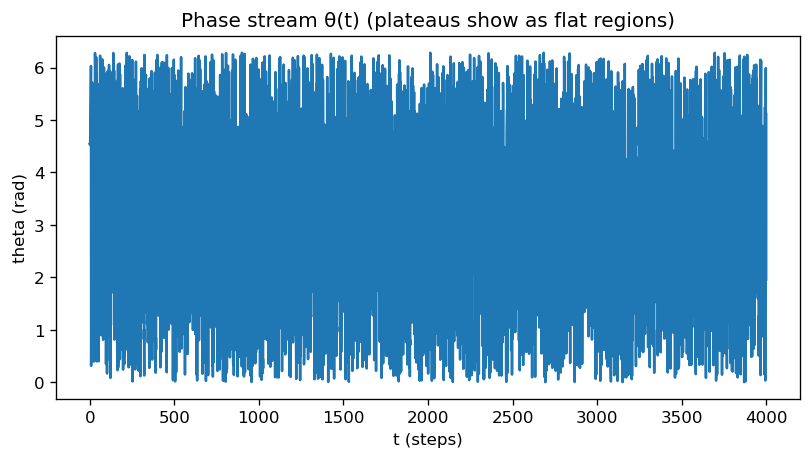

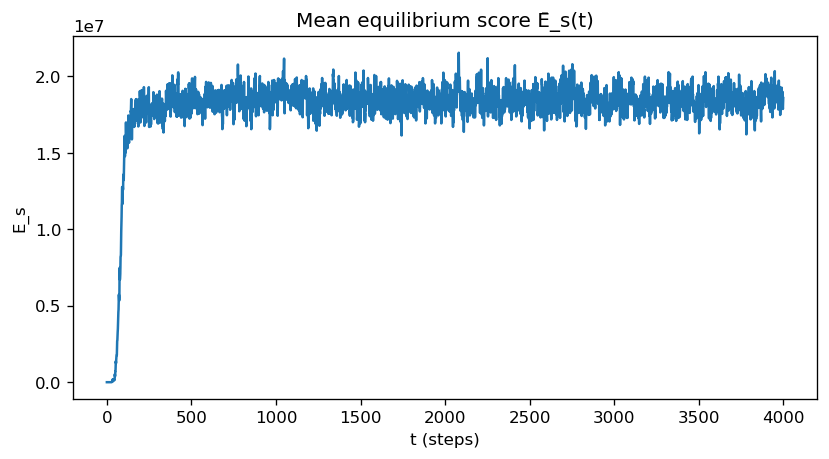

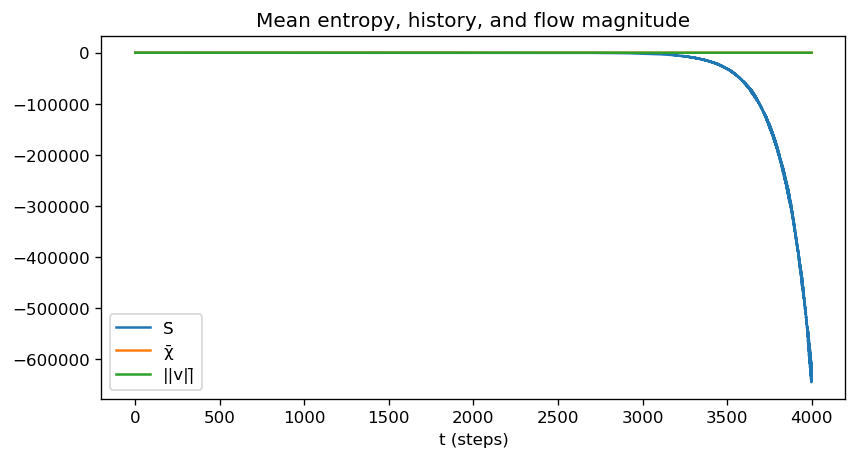

In [15]:

theta = results["theta"]
Esbar = results["Esbar"]
Sbar = results["Sbar"]
chibar = results["chibar"]
vmag = results["vmag"]

t = np.arange(len(theta))  # steps
fig = plt.figure(figsize=(8,4))
plt.plot(t, theta)
plt.xlabel("t (steps)")
plt.ylabel("theta (rad)")
plt.title("Phase stream θ(t) (plateaus show as flat regions)")
plt.show()

fig = plt.figure(figsize=(8,4))
plt.plot(t, Esbar)
plt.xlabel("t (steps)")
plt.ylabel("Ē_s")
plt.title("Mean equilibrium score Ē_s(t)")
plt.show()

fig = plt.figure(figsize=(8,4))
plt.plot(t, Sbar, label="S̄")
plt.plot(t, chibar, label="χ̄")
plt.plot(t, vmag, label="||v||̄")
plt.xlabel("t (steps)")
plt.title("Mean entropy, history, and flow magnitude")
plt.legend()
plt.show()


## Plateau detection (simple)
We mark steps where |Δθ| is below a threshold for a sustained window.


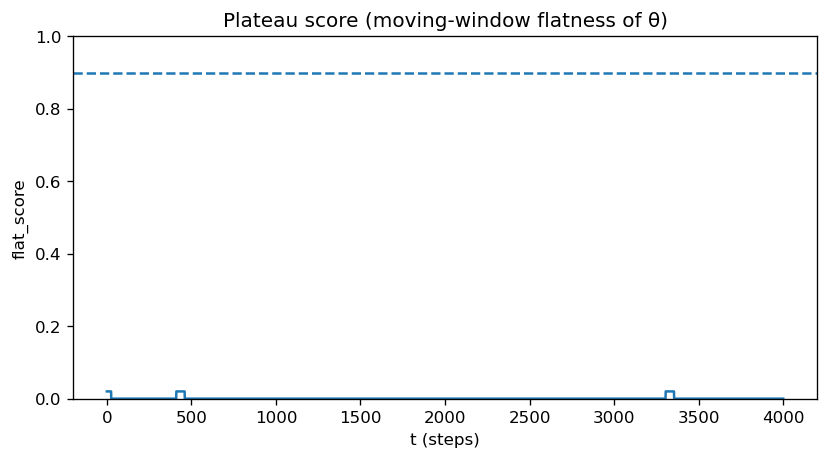

Plateau-heavy steps: 0 of 4001


In [16]:

dtheta = np.abs(np.diff(theta, prepend=theta[0]))
thr = 1e-3
window = 50

is_flat = dtheta < thr
# moving window fraction flat
flat_score = np.convolve(is_flat.astype(float), np.ones(window)/window, mode="same")

fig = plt.figure(figsize=(8,4))
plt.plot(flat_score)
plt.axhline(0.9, linestyle="--")
plt.ylim(0,1)
plt.xlabel("t (steps)")
plt.ylabel("flat_score")
plt.title("Plateau score (moving-window flatness of θ)")
plt.show()

plateau_steps = np.where(flat_score > 0.9)[0]
print("Plateau-heavy steps:", len(plateau_steps), "of", len(theta))


## Field snapshots
We visualize Φ, S, χ, and vorticity at selected times.


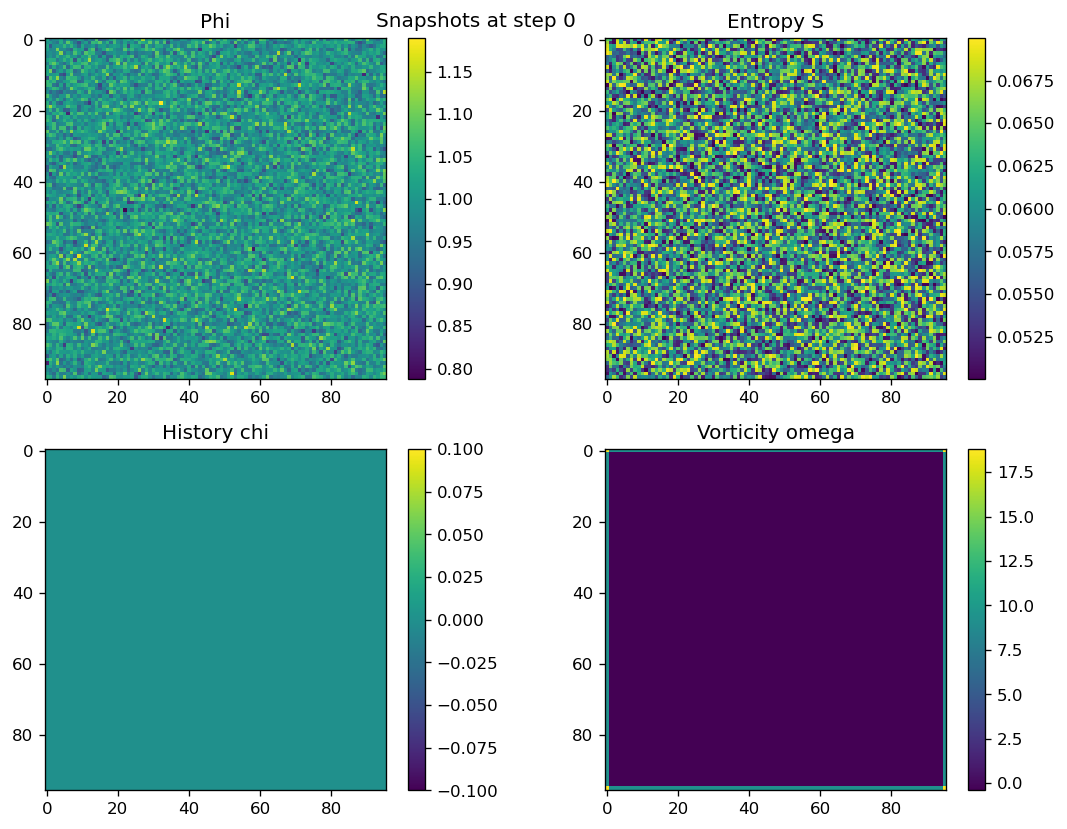

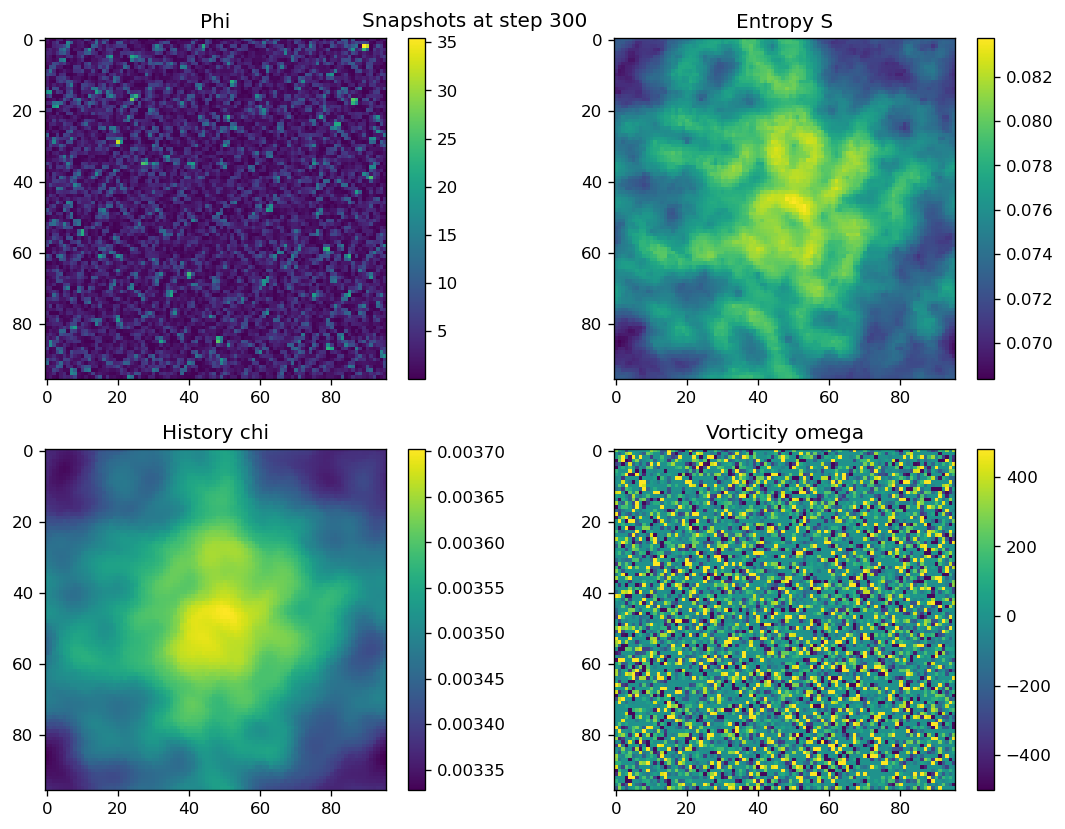

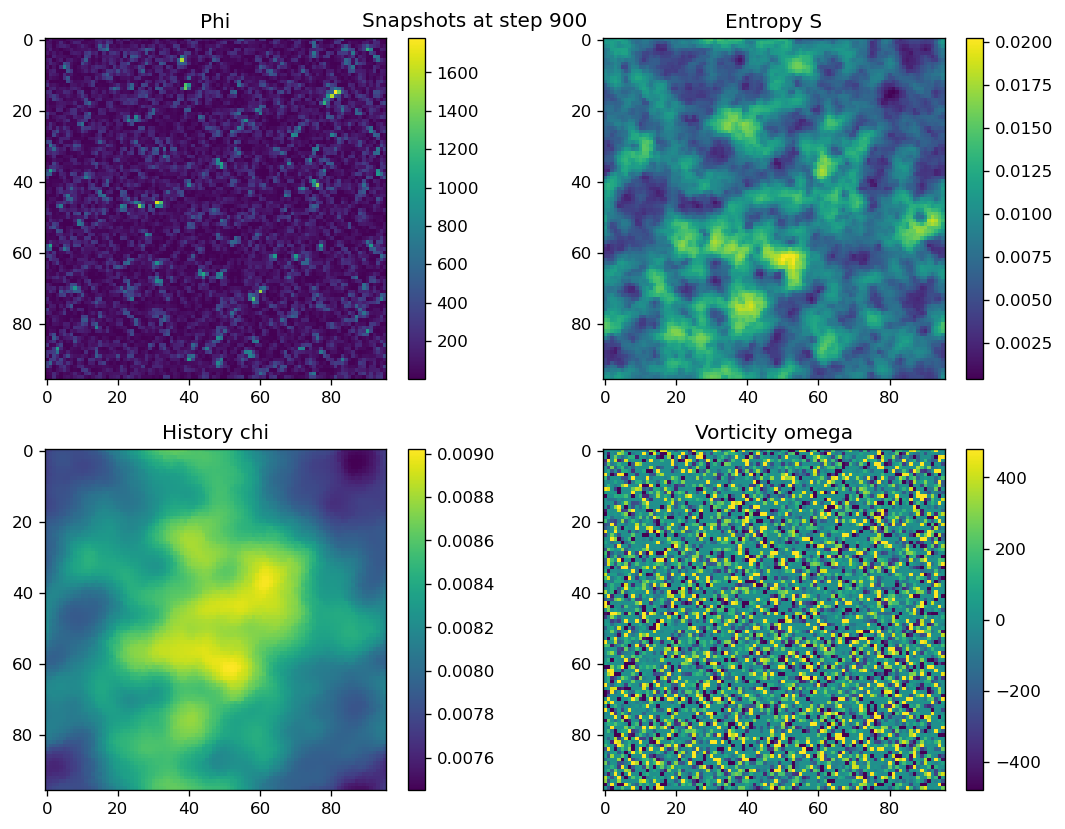

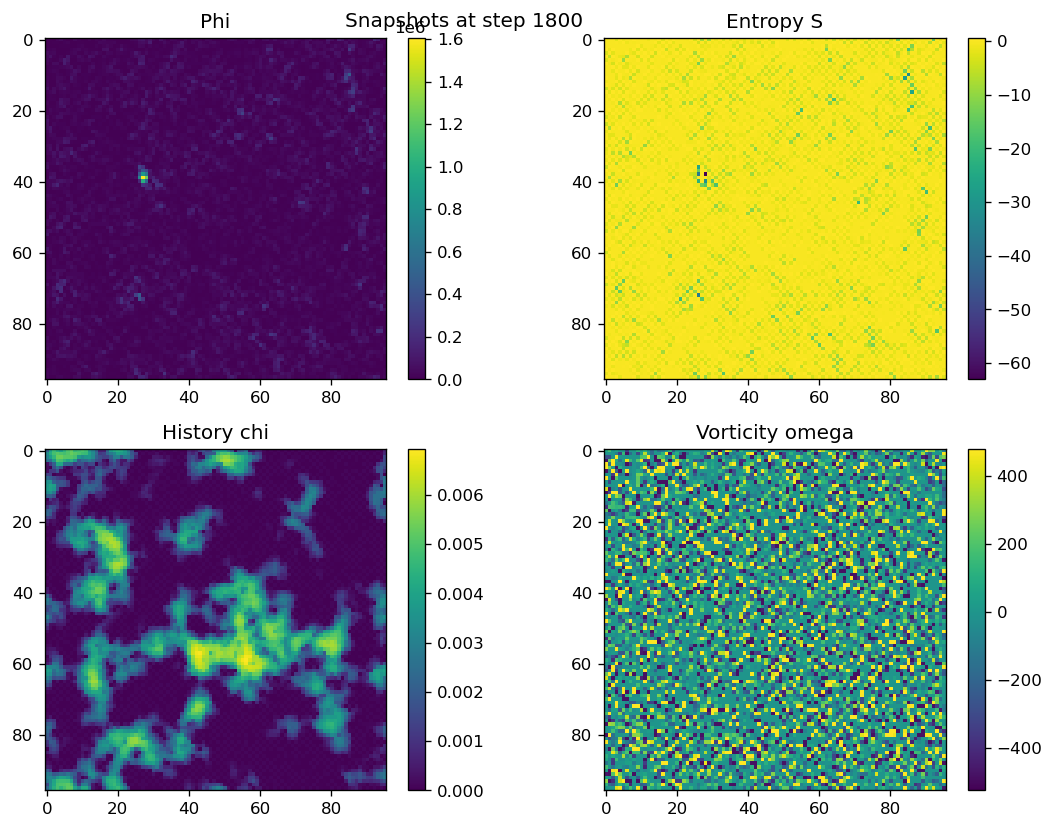

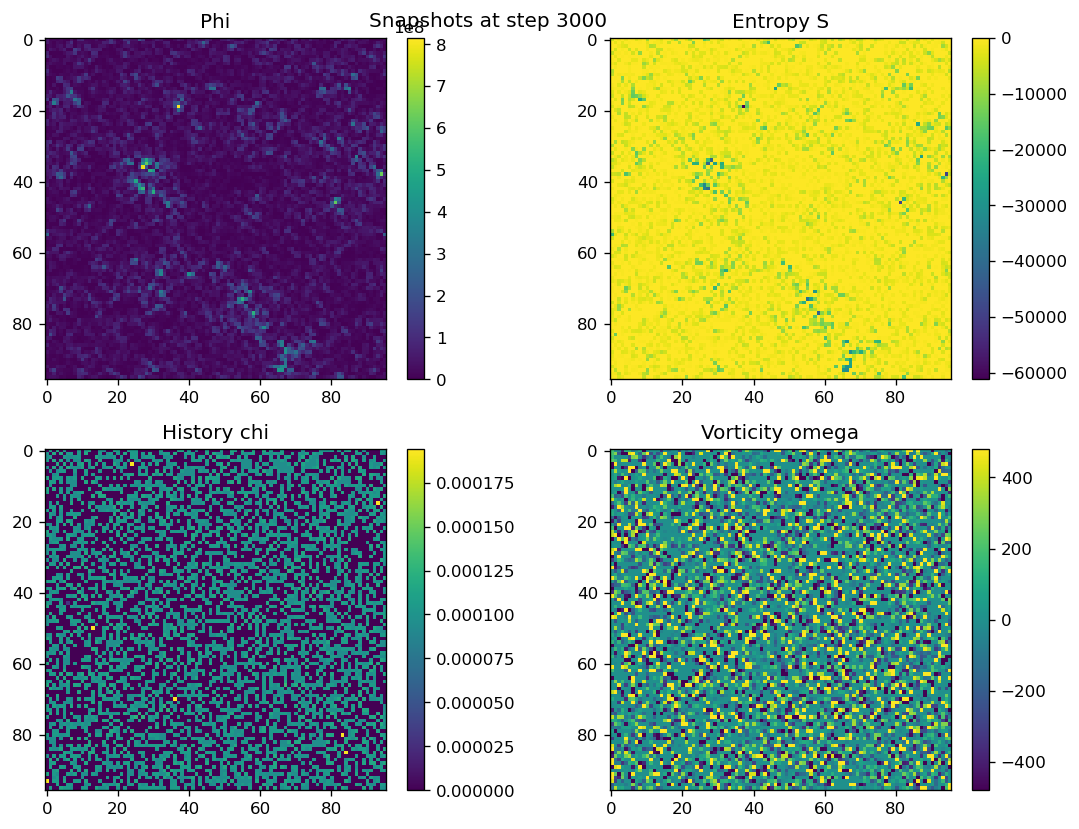

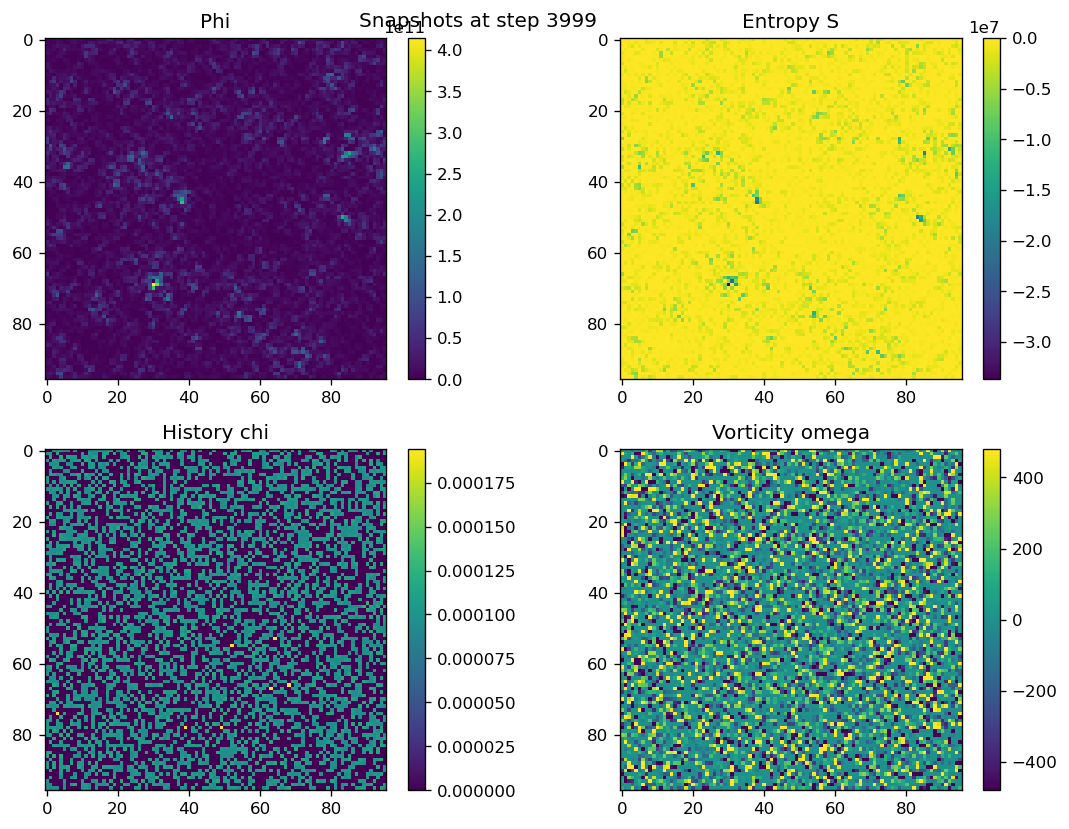

In [17]:

def curl_z(vx, vy, dx, dy):
    # local helper (periodic)
    def roll(a, s, ax): return np.roll(a, s, axis=ax)
    def grad_x(f, dx): return (roll(f,-1,1)-roll(f,1,1))/(2*dx)
    def grad_y(f, dy): return (roll(f,-1,0)-roll(f,1,0))/(2*dy)
    return grad_x(vy, dx) - grad_y(vx, dy)

p = P()
dx = p.Lx/p.nx
dy = p.Ly/p.ny

for n, snap in results["snaps"].items():
    Phi = snap["Phi"]
    S = snap["S"]
    chi = snap["chi"]
    vx = snap["vx"]
    vy = snap["vy"]
    vort = curl_z(vx, vy, dx, dy)

    fig = plt.figure(figsize=(10,7))
    plt.suptitle(f"Snapshots at step {n}")

    ax1 = plt.subplot(2,2,1)
    im = ax1.imshow(Phi)
    ax1.set_title("Phi")
    plt.colorbar(im, ax=ax1, fraction=0.046, pad=0.04)

    ax2 = plt.subplot(2,2,2)
    im = ax2.imshow(S)
    ax2.set_title("Entropy S")
    plt.colorbar(im, ax=ax2, fraction=0.046, pad=0.04)

    ax3 = plt.subplot(2,2,3)
    im = ax3.imshow(chi)
    ax3.set_title("History chi")
    plt.colorbar(im, ax=ax3, fraction=0.046, pad=0.04)

    ax4 = plt.subplot(2,2,4)
    im = ax4.imshow(vort)
    ax4.set_title("Vorticity omega")
    plt.colorbar(im, ax=ax4, fraction=0.046, pad=0.04)

    plt.tight_layout()
    plt.show()


## Optional: quantum gate angles from flow (probe)
If Qiskit is installed, we can build a circuit snapshot from the final θ(t) and mean v.


In [4]:
try:
    from rsvp_quantum_vector_gates import normalize_v, angles_from_v_linear, build_hybrid_circuit
    # use final snapshot
    last_step = max(results["snaps"].keys())
    snap = results["snaps"][last_step]
    vx_bar = float(snap["vx"].mean())
    vy_bar = float(snap["vy"].mean())

    vx_n, vy_n = normalize_v(vx_bar, vy_bar, v_scale=0.5)
    thx, thy = angles_from_v_linear(vx_n, vy_n)

    thz = float(results["theta"][-1])
    qc = build_hybrid_circuit(thz, thx, thy)
    print("Built circuit with angles:")
    print("RZ =", thz, "RX =", thx, "RY =", thy)
    print(qc.draw(output="text"))
except Exception as e:
    print("Qiskit not available or circuit build failed:", e)


Qiskit not available or circuit build failed: name 'results' is not defined


In [5]:
import sys
print(sys.executable)
print(sys.version)


C:\ProgramData\Anaconda3\python.exe
3.8.3 (default, Jul  2 2020, 17:30:36) [MSC v.1916 64 bit (AMD64)]
